# Pose Comparison Example

This notebook demonstrates how to use the PoseComparator.

# 1 Setup

In [4]:
import os
import sys
from pathlib import Path

# Ensure project root is on sys.path so `libraries` imports work
project_root = Path.cwd().resolve()
if not (project_root / "libraries").exists():
    if project_root.name == "mediapipe":
        project_root = project_root.parent.parent  # .../coachKata
    elif project_root.name == "notebooks":
        project_root = project_root.parent  # .../coachKata
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
print(f"Python path updated -> {project_root}")

try:
    from libraries.src.coackata.compare_image import PoseComparator
    print("✅ Successfully imported PoseComparator")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Make sure you're using the 'Coach Kata (uv)' kernel and ran `uv run poe jupyter`")

Python path updated -> /Users/chang/Documents/dev/git/ml/coachKata
✅ Successfully imported PoseComparator


# 2 Inference

In [5]:
teacher_image_path = "/Users/chang/Documents/dev/git/ml/coachKata/data/pickelball/drop-shovel-1.png"  # UPDATE THIS
student_image_path = "/Users/chang/Documents/dev/git/ml/coachKata/data/pickelball/drop-shovel-2.png"  # UPDATE THIS
!ls $teacher_image_path

/Users/chang/Documents/dev/git/ml/coachKata/data/pickelball/drop-shovel-1.png


✅ Setup complete - Python path updated
✅ Successfully imported PoseComparator
✅ PoseComparator initialized successfully
📐 Available joints: 11

📋 Available joints for analysis:
    1. Elbow Right
    2. Elbow Left
    3. Shoulder Right
    4. Shoulder Left
    5. Hip Right
    6. Hip Left
    7. Knee Right
    8. Knee Left
    9. Torso Tilt
   10. Ankle Right
   11. Ankle Left
Loading images...
Teacher image: (262, 183, 3)
Student image: (295, 246, 3)

Detecting poses and comparing angles...


I0000 00:00:1765946969.952669 334579899 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.3), renderer: Apple M4
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1765946970.025594 334583908 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765946970.077035 334583914 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1765946970.127298 334583911 landmark_projection_calculator.cc:186] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.



📐 Joint Angle Comparisons:
------------------------------------------------------------
🔴 Elbow Right:
   Teacher: 115.3° | Student: 160.6° | Diff: +45.3°
✅ Elbow Left:
   Teacher: 107.9° | Student: 105.2° | Diff: -2.7°
🔴 Shoulder Right:
   Teacher: 39.7° | Student: 64.0° | Diff: +24.3°
✅ Shoulder Left:
   Teacher: 25.5° | Student: 17.6° | Diff: -7.8°
✅ Hip Right:
   Teacher: 134.3° | Student: 124.3° | Diff: -9.9°
🔴 Hip Left:
   Teacher: 143.6° | Student: 166.4° | Diff: +22.8°
✅ Knee Right:
   Teacher: 166.2° | Student: 158.2° | Diff: -8.0°
✅ Knee Left:
   Teacher: 175.7° | Student: 169.0° | Diff: -6.7°
✅ Torso Tilt:
   Teacher: 107.2° | Student: 103.7° | Diff: -3.5°
🔴 Ankle Right:
   Teacher: 172.2° | Student: 143.4° | Diff: -28.9°
🔴 Ankle Left:
   Teacher: 168.7° | Student: 112.6° | Diff: -56.1°

💡 Coaching Feedback:
------------------------------------------------------------
🔴 Elbow Right: Increase angle by 45.3°
✅ Elbow Left: Good form (±2.7°)
🔴 Shoulder Right: Increase angle by 

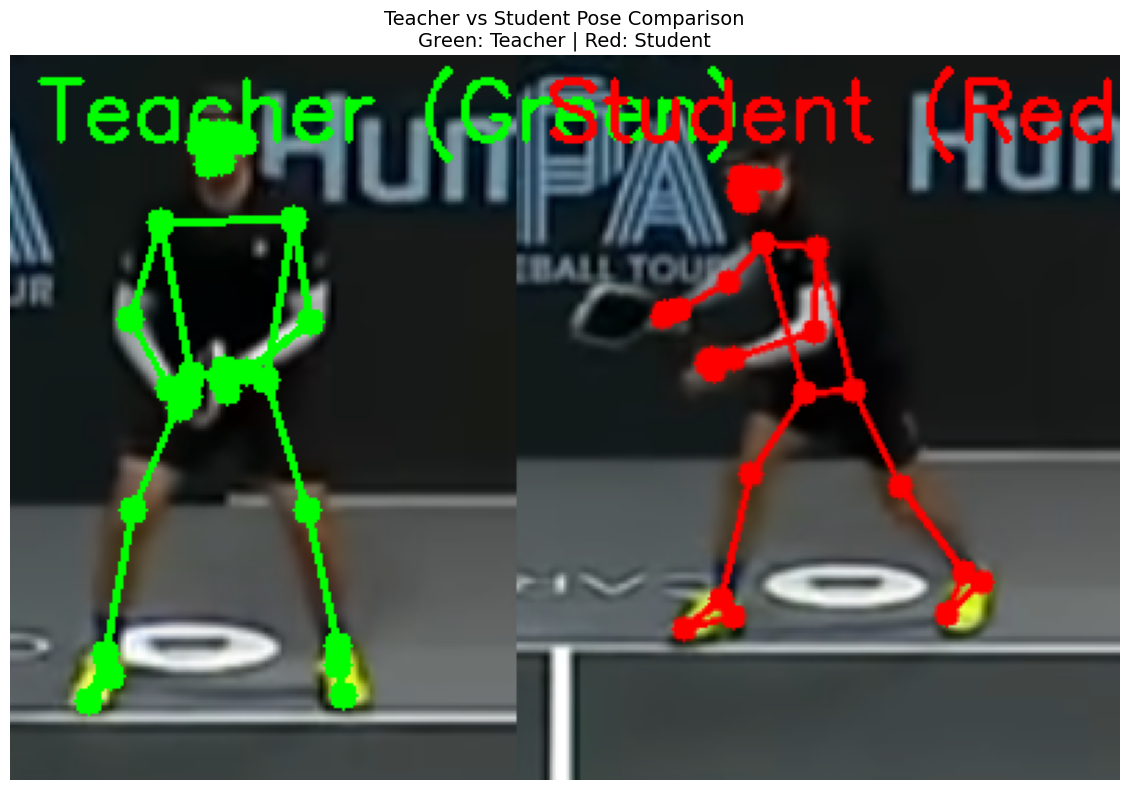

📐 Available joints for angle analysis:
--------------------------------------------------
 1. Elbow Right: Shoulder-Elbow-Wrist
 2. Elbow Left: Shoulder-Elbow-Wrist
 3. Shoulder Right: Hip-Shoulder-Elbow
 4. Shoulder Left: Hip-Shoulder-Elbow
 5. Hip Right: Knee-Hip-Shoulder
 6. Hip Left: Knee-Hip-Shoulder
 7. Knee Right: Hip-Knee-Ankle
 8. Knee Left: Hip-Knee-Ankle
 9. Ankle Right: Knee-Ankle-Foot
10. Ankle Left: Knee-Ankle-Foot
11. Torso Tilt: Left hip-Right hip-Right shoulder

💡 Each joint angle is calculated using three landmarks:
   - Point A: First landmark
   - Point B: Middle landmark (the joint being measured)
   - Point C: Third landmark

   The angle is measured at Point B between lines A-B and B-C.
💻 Command Line Usage:
------------------------------

Basic comparison:
  python compare_image.py teacher.jpg student.jpg

With coaching feedback:
  python compare_image.py teacher.jpg student.jpg --feedback

Save visualization:
  python compare_image.py teacher.jpg student.jpg --

In [6]:
# Pose Comparison Sample Code for Jupyter Notebook
# Copy and paste these cells into your Jupyter notebook

# ============================================================================
# CELL 1: Setup and Imports
# ============================================================================

# Add the project root to Python path
import sys

sys.path.insert(0, os.path.abspath('..'))

# Import required libraries
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("✅ Setup complete - Python path updated")

# ============================================================================
# CELL 2: Import PoseComparator
# ============================================================================

# Import the pose comparator
try:
    from libraries.src.coackata.compare_image import PoseComparator
    print("✅ Successfully imported PoseComparator")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("Make sure you're using the 'Coach Kata (uv)' kernel")

# ============================================================================
# CELL 3: Initialize PoseComparator
# ============================================================================

# Initialize the comparator
try:
    comparator = PoseComparator()
    print("✅ PoseComparator initialized successfully")
    print(f"📐 Available joints: {len(comparator.JOINTS)}")

    # Show available joints
    print("\n📋 Available joints for analysis:")
    for i, joint_name in enumerate(comparator.JOINTS.keys(), 1):
        print(f"   {i:2d}. {joint_name.replace('_', ' ').title()}")

except Exception as e:
    print(f"❌ Error initializing PoseComparator: {e}")

# ============================================================================
# CELL 4: Example Usage (Update paths with your images)
# ============================================================================

# Example: Load and compare poses
# Replace these paths with your actual image files

# Check if files exist
if os.path.exists(teacher_image_path) and os.path.exists(student_image_path):
    print("Loading images...")

    # Load images
    teacher_img = comparator.load_image(teacher_image_path)
    student_img = comparator.load_image(student_image_path)

    print(f"Teacher image: {teacher_img.shape}")
    print(f"Student image: {student_img.shape}")

    # Compare poses
    print("\nDetecting poses and comparing angles...")
    results = comparator.compare_poses(teacher_img, student_img)

    # Display results
    print("\n📐 Joint Angle Comparisons:")
    print("-" * 60)
    for joint_name, diff_data in results['angle_differences'].items():
        if diff_data is not None:
            teacher_angle = diff_data['teacher_angle']
            student_angle = diff_data['student_angle']
            difference = diff_data['difference']
            abs_diff = diff_data['absolute_diff']

            status = "✅" if abs_diff <= 10.0 else "🔴"
            print(f"{status} {joint_name.replace('_', ' ').title()}:")
            print(f"   Teacher: {teacher_angle:.1f}° | Student: {student_angle:.1f}° | Diff: {difference:+.1f}°")

    # Generate feedback
    print("\n💡 Coaching Feedback:")
    print("-" * 60)
    feedback = comparator.generate_feedback(results['angle_differences'])
    for message in feedback:
        print(message)

    # Summary
    total_joints = len(results['angle_differences'])
    good_joints = sum(1 for diff_data in results['angle_differences'].values()
                     if diff_data is not None and diff_data['absolute_diff'] <= 10.0)

    print("\n📈 Summary:")
    print(f"Total joints analyzed: {total_joints}")
    print(f"Joints with good form: {good_joints}")
    print(f"Form accuracy: {good_joints/total_joints*100:.1f}%")

else:
    print("❌ Image files not found. Please update the paths above with your actual image files.")
    print("\nExample usage:")
    print("teacher_image_path = 'teacher_squat.jpg'")
    print("student_image_path = 'student_squat.jpg'")

# ============================================================================
# CELL 5: Visualization (Run after Cell 4)
# ============================================================================

# Example: Create visualization
if 'results' in locals():
    print("Creating side-by-side visualization...")

    # Create visualization
    combined = comparator.visualize_comparison(
        teacher_img, student_img,
        results['teacher_landmarks'], results['student_landmarks']
    )

    # Display the combined image
    plt.figure(figsize=(15, 8))
    plt.imshow(cv2.cvtColor(combined, cv2.COLOR_BGR2RGB))
    plt.title('Teacher vs Student Pose Comparison\nGreen: Teacher | Red: Student', fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Optionally save the visualization
    # cv2.imwrite('pose_comparison.png', combined)
    # print("Visualization saved as 'pose_comparison.png'")
else:
    print("No results available. Run the comparison cell above first.")

# ============================================================================
# CELL 6: Joint Analysis Details
# ============================================================================

# Display available joints and their landmark definitions
if 'comparator' in locals():
    print("📐 Available joints for angle analysis:")
    print("-" * 50)

    joint_definitions = {
        "elbow_right": "Shoulder-Elbow-Wrist",
        "elbow_left": "Shoulder-Elbow-Wrist",
        "shoulder_right": "Hip-Shoulder-Elbow",
        "shoulder_left": "Hip-Shoulder-Elbow",
        "hip_right": "Knee-Hip-Shoulder",
        "hip_left": "Knee-Hip-Shoulder",
        "knee_right": "Hip-Knee-Ankle",
        "knee_left": "Hip-Knee-Ankle",
        "ankle_right": "Knee-Ankle-Foot",
        "ankle_left": "Knee-Ankle-Foot",
        "torso_tilt": "Left hip-Right hip-Right shoulder"
    }

    for i, (joint_name, definition) in enumerate(joint_definitions.items(), 1):
        print(f"{i:2d}. {joint_name.replace('_', ' ').title()}: {definition}")

    print("\n💡 Each joint angle is calculated using three landmarks:")
    print("   - Point A: First landmark")
    print("   - Point B: Middle landmark (the joint being measured)")
    print("   - Point C: Third landmark")
    print("\n   The angle is measured at Point B between lines A-B and B-C.")

# ============================================================================
# CELL 7: Command Line Usage Examples
# ============================================================================

# Show command line usage examples
print("💻 Command Line Usage:")
print("-" * 30)
print("\nBasic comparison:")
print("  python compare_image.py teacher.jpg student.jpg")
print("\nWith coaching feedback:")
print("  python compare_image.py teacher.jpg student.jpg --feedback")
print("\nSave visualization:")
print("  python compare_image.py teacher.jpg student.jpg --output comparison.png")
print("\nCustom threshold:")
print("  python compare_image.py teacher.jpg student.jpg --threshold 15.0")
print("\nUsing poe task:")
print("  uv run poe compare-poses teacher.jpg student.jpg --feedback")

# ============================================================================
# CELL 8: Test with Sample Data (Optional)
# ============================================================================

# Create a simple test to verify the module works
print("🧪 Testing PoseComparator functionality...")

try:
    # Test if we can create a simple test image
    test_img = np.zeros((480, 640, 3), dtype=np.uint8)
    test_img[:] = (128, 128, 128)  # Gray background

    # Try to detect pose (will likely fail with no person, but tests the setup)
    landmarks = comparator.detect_pose(test_img)

    if landmarks is None:
        print("✅ Pose detection working (no pose detected in test image - expected)")
    else:
        print("✅ Pose detection working (pose detected)")

    print("✅ All tests passed - module is ready to use!")

except Exception as e:
    print(f"❌ Test failed: {e}")

# ============================================================================
# CELL 9: Custom Analysis Example
# ============================================================================

# Example of custom analysis (run after loading images)
if 'results' in locals():
    print("🔍 Custom Analysis Example:")
    print("-" * 40)

    # Find the joint with the biggest difference
    max_diff_joint = None
    max_diff_value = 0

    for joint_name, diff_data in results['angle_differences'].items():
        if diff_data is not None:
            abs_diff = diff_data['absolute_diff']
            if abs_diff > max_diff_value:
                max_diff_value = abs_diff
                max_diff_joint = joint_name

    if max_diff_joint:
        print(f"Biggest difference: {max_diff_joint.replace('_', ' ').title()} ({max_diff_value:.1f}°)")

        # Analyze specific joint
        joint_data = results['angle_differences'][max_diff_joint]
        teacher_angle = joint_data['teacher_angle']
        student_angle = joint_data['student_angle']
        difference = joint_data['difference']

        print(f"Teacher angle: {teacher_angle:.1f}°")
        print(f"Student angle: {student_angle:.1f}°")

        if difference > 0:
            print(f"Student needs to decrease angle by {difference:.1f}°")
        else:
            print(f"Student needs to increase angle by {abs(difference):.1f}°")
else:
    print("No results available. Run the comparison cell first.")

# ============================================================================
# END OF SAMPLE CODE
# ============================================================================